In [1]:
from Bern3D import *
from DiffSim import *
import numpy as np
import numba
from numba.typed import List
numba.set_num_threads(4)
rng = np.random.default_rng()
def split_mean(y, n):
    chunks = np.array_split(y, n)
    return np.array([np.mean(chunk) for chunk in chunks])
ylabs = [r'$y_D$', r'$y_R$', r'$y_C$']
leglabs = [r'$a_D$', r'$a_R$', r'$a_C$']
plt.rc('font', size=8) 


In [2]:
def plot_diff_paths(diffsims, fig, subtitles, ylabs=['',''], max_step=inf, sharey=True):
    fig.clear()
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    diff_axs = fig.subplots(3, 2, sharex=True, sharey=sharey)
    for s in range(10):
        for i, diffsim in enumerate(diffsims):
            path = sample_diff_path(diffsim, only_correct=True, max_step=max_step, logodds=True)
            path[:,1:path.shape[1]-1] = path[:,1:path.shape[1]-1] + rng.uniform(-.25, .25, size=(3,path.shape[1]-2))
            t = np.linspace(0, path.shape[1]-1, path.shape[1])
            for j in range(3):
                diff_axs[j,i].plot(t, path[j,:], color=colors[j], linewidth=0.75, alpha=0.5, markevery=[-1], marker='o')

    for ax, label in zip(diff_axs[:,0], ylabs):
        ax.set_ylabel(label)

    for ax, title in zip(diff_axs[0,:], subtitles):
        ax.set_title(title)

    return diff_axs

def plot_diffs_together(diffsim, fig):
    ax = fig.subplots(2, 1, sharex=False, height_ratios=(1, 0.2))
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    path = sample_diff_path(diffsim, only_correct=True, logodds=True)
    t = np.linspace(0, path.shape[1]-1, path.shape[1])
    offsets = (0.07, 0, -0.07)
    labels = ('Distractor', 'Task-relevant', 'Task cue')
    for j in range(3):
        ax[0].plot(t, path[j,:] + offsets[j], color=colors[j], linewidth=2, markevery=[-1], marker='o', label=labels[j])
    fig.legend(loc='outside right center', fontsize='large')
    
    ypos = (0.1, 0.2, 0.3)
    dp = np.diff(path) != 0
    for j in range(3):
        ax[1].scatter(t[np.append(dp[j,:], False)], np.full(np.sum(dp[j,:]), ypos[j]))
    ax[1].set_ylim((0, 0.4))
    ax[1].set_xticks([])
    ax[1].set_yticks([])
    ax[1].set_xlabel('Attention allocation', fontsize='large')
    ax[0].set_ylabel('Evidence', fontsize='large')
    ax[0].set_xlabel('Time', fontsize='large')
    return ax 

def plot_choice_rates(diffsims, fig, subtitles, leglabs, nbins=10):
    fig.clear()
    choice_axs = fig.subplots(1, 2, sharex=True, sharey=True)
    for diffsim, ax in zip(diffsims, choice_axs):
        foo = np.zeros((3,nbins))
        for p in range(1000):
            path = sample_diff_path(diffsim)
            dp = np.diff(path) != 0
            foo = foo + np.array([split_mean(dp[i,:],nbins) for i in range(3)])
        foo = foo/1000
        t = np.linspace(1,nbins,nbins)
        juh = [ax.plot(t, foo[j,:])[0] for j in range(3)]
        ax.set_xticks([1,nbins-1],["Early","Late"])

    for ax, title in zip(choice_axs, subtitles):
        ax.set_title(title)
        ax.set_ylabel("Choice prob.")

    fig.legend(juh, leglabs, ncols=3, loc="outside lower center")

    return choice_axs

def plot_rt_contrast(diffsims, fig, ylim=[], title=[], xtick=[]):
    fig.clear()
    eff_ax = fig.subplots()
    rt_inc = performance(diffsims[1])[0]
    rt_con = performance(diffsims[0])[0]
    eff_ax.bar(xtick, [rt_con, rt_inc])
    eff_ax.set_ylabel("Reaction Time")
    eff_ax.set_title(title)
    if len(ylim) == 2:
        eff_ax.set_ylim(ylim)

    return  eff_ax


In [3]:
ex = Bern3Diff(theta=0.6, cost=-.001, sigma=(0.6,0.6), pvalid=1.0, task_prior=0.5, state_range=30)

161


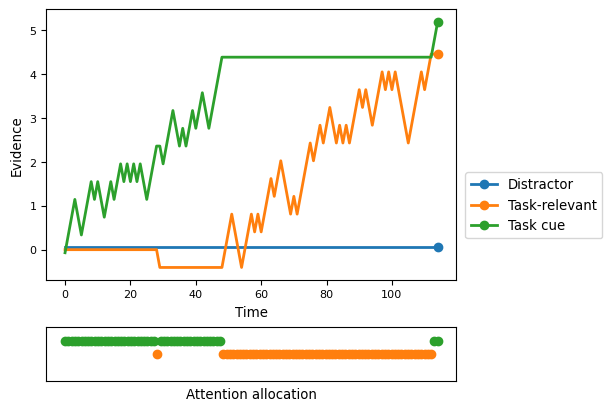

In [15]:
fig = plt.figure(layout='constrained', figsize=(6, 4))
ax = plot_diffs_together(DiffSim(ex, (True, True)), fig)
fig.savefig('taskeasy.pdf')

In [16]:
rep = Bern3Diff(theta=0.6, cost=-.001, sigma=(0.6,0.6), pvalid=1.0, task_prior=0.9, state_range=30)
switch = Bern3Diff(theta=0.6, cost=-.001, sigma=(0.6,0.6), pvalid=1.0, task_prior=0.1, state_range=30)

160
160


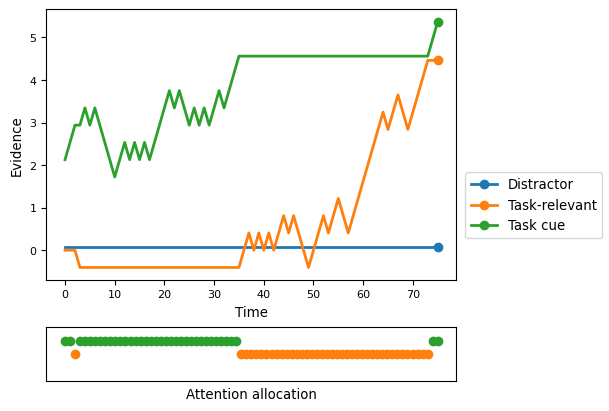

In [52]:
fig = plt.figure(layout='constrained', figsize=(6, 4))
ax = plot_diffs_together(DiffSim(rep, (True, True)), fig)
fig.savefig('taskeasy_repeat.pdf')

In [60]:
ex2 = Bern3Diff(theta=0.6, cost=-.001, sigma=(0.75,0.75), pvalid=1.0, task_prior=0.5, state_range=30)

47


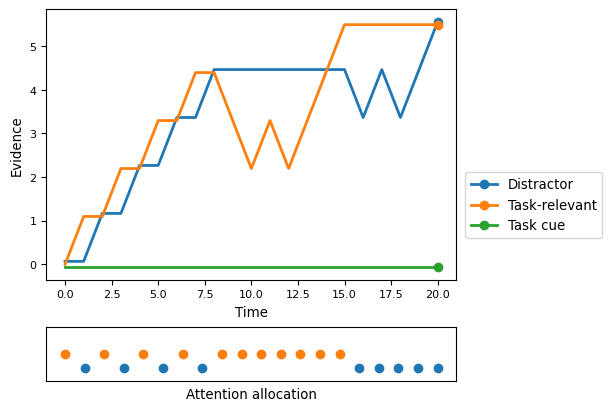

In [87]:
fig = plt.figure(layout='constrained', figsize=(6, 4))
ax = plot_diffs_together(DiffSim(ex2, (True, True)), fig)
#fig.savefig('taskhard_inc.pdf')

In [90]:
ax[0].set_xlim((-2, 35))
ax[1].set_xlim((-2, 35))
fig.savefig('taskhard_congruent.pdf')

In [3]:
task_easy = Bern3Diff(theta=0.7, cost=-.001, sigma=(0.7,0.7), pvalid=1.0, task_prior=0.5, state_range=30)
task_hard = Bern3Diff(theta=0.6, cost=-.001, sigma=(0.75,0.75), pvalid=1.0, task_prior=0.5, state_range=30)

54
47


In [4]:
bigfig = plt.figure(layout='constrained', figsize=(10,8))
easyfig, hardfig = bigfig.subfigures(2, 1)

hard_diffsims = (DiffSim(task_hard, (True, True)), DiffSim(task_hard, (False, True)))
hf_diff, hf_choice, hf_eff = hardfig.subfigures(1,3, width_ratios=(1.1, .9, 0.4))
hardfig.suptitle(r"Low task cue drift ($\sigma_c < \sigma_s$)")

easy_diffsims = (DiffSim(task_easy, (True, True)), DiffSim(task_easy, (False, True)))
ef_diff, ef_choice, ef_eff = easyfig.subfigures(1,3, width_ratios=(1.1, .9, 0.4))
easyfig.suptitle(r"High task cue drift ($\sigma_c \geq \sigma_s$)")

subtitles = ["Congruent", "Incongruent"]

<Figure size 1000x800 with 0 Axes>

In [11]:
axs_easy_choice = plot_choice_rates(easy_diffsims, ef_choice, ["b) Congruent", "Incongruent"], leglabs, 5)
# axs_easy_choice[0].set_title("b)", loc="left")

ax_easy_eff = plot_rt_contrast(easy_diffsims, ef_eff, ylim=[20, 100], title="c) Stable", xtick=("Con.", "Inc."))

axs_hard_choice = plot_choice_rates(hard_diffsims, hf_choice, ["e) Congruent", "Incongruent"], leglabs, 10)
# axs_hard_choice[0].set_title("e)", loc="left")

axs_hard_eff = plot_rt_contrast(hard_diffsims, hf_eff, ylim=[20, 100], title="f) Unstable", xtick=("Con.", "Inc."))


In [12]:
axs_easy_paths = plot_diff_paths(easy_diffsims, ef_diff, subtitles, ylabs, 50)
axs_easy_paths[0,0].set_title("a)", loc="left")

Text(0.0, 1.0, 'a)')

In [13]:
axs_hard_paths = plot_diff_paths(hard_diffsims, hf_diff, subtitles, ylabs, 100, sharey=True)
axs_hard_paths[0,0].set_title("d)", loc="left")

Text(0.0, 1.0, 'd)')

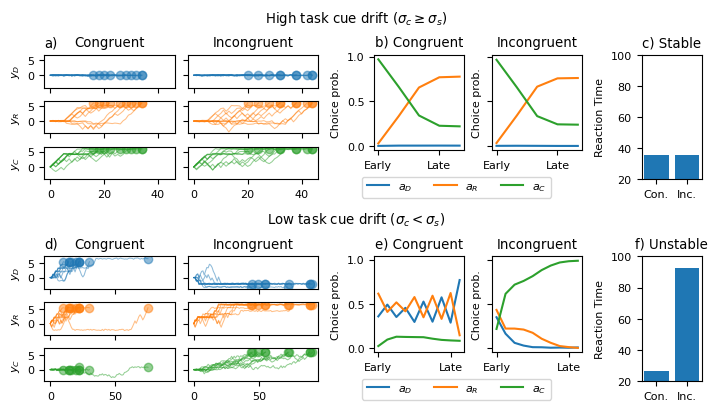

In [14]:
bigfig.set_figheight(4)
bigfig.set_figwidth(7)
bigfig.savefig("stability.pdf", bbox_inches="tight")
bigfig

In [529]:
task_easy_switch = Bern3Diff(theta=0.7, cost=-.001, sigma=(0.7,0.7), pvalid=1.0, task_prior=0.1, state_range=30)
task_easy_repeat = Bern3Diff(theta=0.7, cost=-.001, sigma=(0.7,0.7), pvalid=1.0, task_prior=0.9, state_range=30)

task_hard_switch = Bern3Diff(theta=0.6, cost=-.001, sigma=(0.8,0.8), pvalid=1.0, task_prior=0.1, state_range=30)
task_hard_repeat = Bern3Diff(theta=0.6, cost=-.001, sigma=(0.8,0.8), pvalid=1.0, task_prior=0.9, state_range=30)

54
54
42
41


In [530]:
bigfig = plt.figure(layout='constrained', figsize=(4,7))
easyfig, hardfig = bigfig.subfigures(2, 1)

hard_diffsims = (DiffSim(task_hard_repeat, (True, True)), DiffSim(task_hard_switch, (True, True)))
hf_diff, hf_choice, hf_eff = hardfig.subfigures(1,3, width_ratios=(1.1, 0.9, 0.4))
hardfig.suptitle(r"Low task cue drift ($\sigma_c < \sigma_s$)")

easy_diffsims = (DiffSim(task_easy_repeat, (True, True)), DiffSim(task_easy_switch, (True, True)))
ef_diff, ef_choice, ef_eff = easyfig.subfigures(1,3, width_ratios=(1.1, .9, 0.4))
easyfig.suptitle(r"High task cue drift ($\sigma_c \geq \sigma_s$)")

subtitles = ["Repeat", "Switch"]

<Figure size 400x700 with 0 Axes>

In [531]:
axs_easy_choice = plot_choice_rates(easy_diffsims, ef_choice, ["b) Repeat", "Switch"], leglabs, 4)
# axs_easy_choice[0].set_title("b)", loc="left")

plot_rt_contrast(easy_diffsims, ef_eff, ylim=[15, 45], title="c) Inflexible", xtick=("Rep.", "Switch"))

axs_hard_choice = plot_choice_rates(hard_diffsims, hf_choice, ["e) Repeat", "Switch"], leglabs, 4)
# axs_hard_choice[0].set_title("e)", loc="left")

plot_rt_contrast(hard_diffsims, hf_eff, ylim=[15, 45], title="f) Flexible", xtick=("Rep.", "Switch"))

<Axes: title={'center': 'f) Flexible'}, ylabel='Reaction Time'>

In [532]:
axs_easy_paths = plot_diff_paths(easy_diffsims, ef_diff, subtitles, ylabs, 60)
axs_easy_paths[0,0].set_title("a)", loc="left")

Text(0.0, 1.0, 'a)')

In [533]:
axs_hard_paths = plot_diff_paths(hard_diffsims, hf_diff, subtitles, ylabs, 30, sharey=True)
axs_hard_paths[0,0].set_title("d)", loc="left")

Text(0.0, 1.0, 'd)')

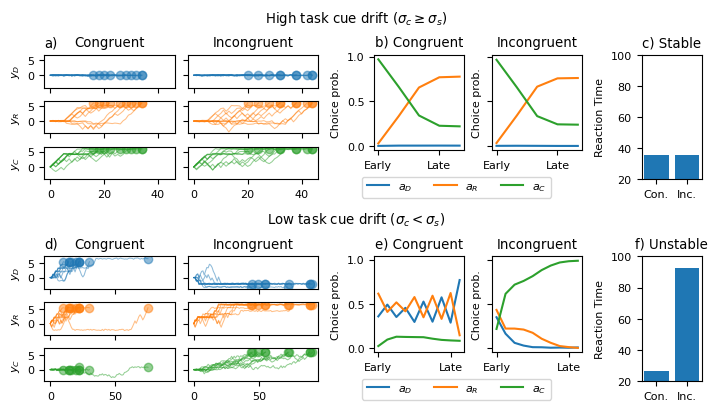

In [15]:
bigfig.set_figheight(4)
bigfig.set_figwidth(7)
bigfig.savefig("flexibility.pdf", bbox_inches="tight")
bigfig

#### alright big stuff now

In [3]:
sigmas = np.linspace(0.55, 0.95, 9)
inc_eff_map = np.empty((len(sigmas), len(sigmas)))

for i, sigma_stim in enumerate(sigmas):
    for j, sigma_cue in enumerate(sigmas):
        b3d = Bern3Diff(theta=sigma_cue, cost=-.005, sigma=(sigma_stim, sigma_stim), pvalid=1.0, task_prior=0.5, state_range=30)
        rt_con = performance(DiffSim(b3d, (True, True)))[0]
        rt_inc = performance(DiffSim(b3d, (False, True)))[0]
        inc_eff_map[i,j] = (rt_inc - rt_con)/rt_con


75
76
76
76
77
76
77
76
76
91
95
94
93
92
90
91
90
90
80
66
64
65
64
65
63
64
63
71
50
46
45
44
44
43
43
42
66
41
33
32
31
30
29
29
29
65
38
29
25
24
24
23
23
22
64
36
26
21
19
17
16
16
16
63
35
25
20
17
15
13
13
12
63
34
24
19
15
13
11
10
9


In [4]:
rep_prob = 0.9
switch_eff_map = np.empty((len(sigmas), len(sigmas)))

for i, sigma_stim in enumerate(sigmas):
    for j, sigma_cue in enumerate(sigmas):
        b3d_rep = Bern3Diff(theta=sigma_cue, cost=-.005, sigma=(sigma_stim, sigma_stim), pvalid=1.0, task_prior=rep_prob, state_range=30)
        b3d_switch = Bern3Diff(theta=sigma_cue, cost=-.005, sigma=(sigma_stim, sigma_stim), pvalid=1.0, task_prior=1-rep_prob, state_range=30)
        rt_rep = performance(DiffSim(b3d_rep, (True, True)))[0]
        rt_switch = performance(DiffSim(b3d_switch, (True, True)))[0]
        switch_eff_map[i,j] = (rt_switch - rt_rep)/rt_rep


76
76
76
76
76
76
76
76
76
77
76
77
76
76
76
76
76
77
91
91
95
95
93
93
92
93
91
92
91
91
91
91
90
90
90
90
80
81
66
66
64
65
64
65
64
64
64
64
63
63
63
64
62
63
71
72
50
50
47
47
45
45
44
44
44
44
43
43
42
43
42
43
66
67
41
42
34
34
32
32
31
31
29
30
29
29
29
30
28
29
65
65
38
39
29
30
25
25
24
25
23
24
22
23
22
23
22
22
64
64
36
36
26
27
21
22
19
19
17
18
16
17
16
17
15
16
64
63
35
35
25
25
20
20
17
17
15
15
14
14
13
14
12
13
63
63
34
34
24
25
19
19
15
16
13
14
11
12
10
10
9
9


In [4]:
task_priors = np.linspace(0.2, 0.8, 3)
stablediff = [Bern3Diff(theta=0.7, cost=-.005, sigma=(0.8, 0.8), pvalid=1.0, task_prior=prior, state_range=30) for prior in task_priors]
flexdiff = [Bern3Diff(theta=0.65, cost=-.005, sigma=(0.85, 0.85), pvalid=1.0, task_prior=prior, state_range=30) for prior in task_priors]

stable_rt_inc = [performance(DiffSim(f, (False, True)))[0] for f in stablediff]
stable_rt_con = [performance(DiffSim(f, (True, True)))[0] for f in stablediff]
flex_rt_inc = [performance(DiffSim(f, (False, True)))[0] for f in flexdiff]
flex_rt_con = [performance(DiffSim(f, (True, True)))[0] for f in flexdiff]


25
25
25
27
26
26


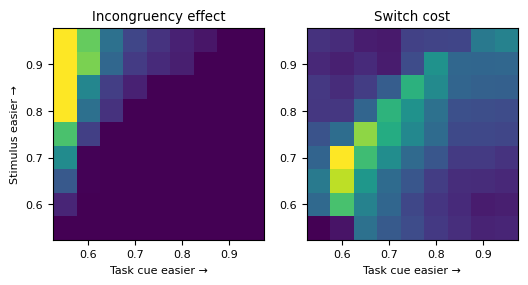

In [27]:
fig, haxs = plt.subplots(1, 2, sharey=False)
fig.set_figheight(3)
fig.set_figwidth(6)

c = haxs[1].pcolormesh(sigmas, sigmas, switch_eff_map)
haxs[1].set_title("Switch cost")

c = haxs[0].pcolormesh(sigmas, sigmas, inc_eff_map, vmax=10)
haxs[0].set_title("Incongruency effect")
haxs[0].set_ylabel("Stimulus easier \u2192")
for ax in haxs:
    ax.set_aspect(1)
    ax.set_xlabel("Task cue easier \u2192")
    ax.set_yticks([.9, .8, .7, .6])

fig.savefig('justheat.pdf')

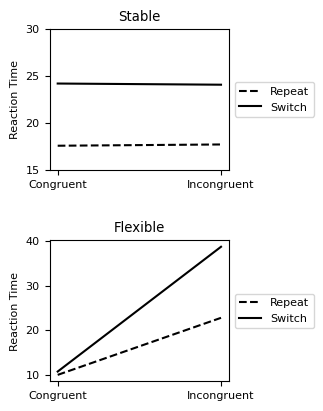

In [8]:
fig, raxs = plt.subplots(2, 1, sharex=False, figsize=(2.4,4))
fig.tight_layout()
for ax, rt_con, rt_inc in zip(raxs, (stable_rt_con, flex_rt_con), (stable_rt_inc, flex_rt_inc)):
    ax.plot([0, 1], [rt_con[2], rt_inc[2]], linestyle='--', color='black', label="Repeat")
    ax.plot([0, 1], [rt_con[0], rt_inc[0]], color='black', label="Switch")
# raxs[0].set_y
raxs[0].set_ylim((15,30))
raxs[0].set_yticks((15, 20, 25, 30))
raxs[0].set_title('Stable')
raxs[1].set_title('Flexible')
raxs[1].set_yticks((10, 20, 30, 40))
for ax in raxs:
    ax.set_xticks((0, 1), labels=("Congruent", "Incongruent"))
    ax.set_ylabel('Reaction Time')
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.subplots_adjust(hspace=0.5)
fig.savefig('justrt.pdf', bbox_inches='tight'   )

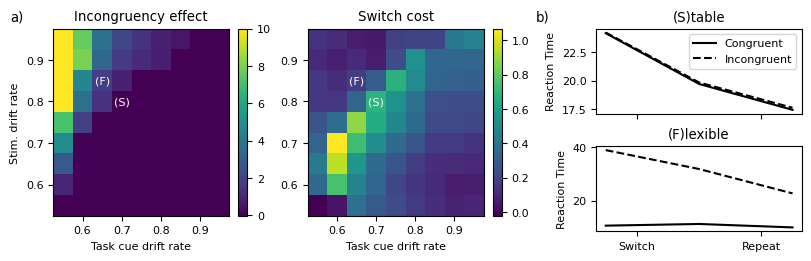

In [11]:
bigfig = plt.figure(layout='constrained', figsize=(8,2.5))
heatfig, rtfig = bigfig.subfigures(1, 2, width_ratios=(1,.5))
heatfig.suptitle("a)", x=0.02, y=.98)
rtfig.suptitle("b)", x=0, y=.98)

haxs = heatfig.subplots(1, 2, sharey=False)
c = haxs[1].pcolormesh(sigmas, sigmas, switch_eff_map)
haxs[1].figure.colorbar(c)
haxs[1].set_title("Switch cost")

c = haxs[0].pcolormesh(sigmas, sigmas, inc_eff_map, vmax=10)
haxs[0].figure.colorbar(c)
haxs[0].set_title("Incongruency effect")
haxs[0].set_ylabel("Stim. drift rate")
for ax in haxs:
    # ax.set_aspect(1)
    ax.set_xlabel("Task cue drift rate")
    ax.text(.65, .85, "(F)", ha="center", va="center", color="w")
    ax.text(.7, .8, "(S)", ha="center", va="center", color="w")


raxs = rtfig.subplots(2, 1, sharex=True)
for ax, rt_con, rt_inc in zip(raxs, (stable_rt_con, flex_rt_con), (stable_rt_inc, flex_rt_inc)):
    ax.plot(task_priors, rt_con, color='black', label="Congruent")
    ax.plot(task_priors, rt_inc, linestyle='--', color='black', label="Incongruent")
raxs[0].legend()
# # ax.set_xlabel('Switch   ' + r'$z_0$' + '  Repeat')
raxs[0].set_title('(S)table')
raxs[1].set_title('(F)lexible')
for ax in raxs:
    ax.set_xticks((0.3,0.7), labels=("Switch", "Repeat"))
    ax.set_ylabel('Reaction Time')


bigfig.savefig("thetradeoff.pdf")

#### soooooftmax

46
45
45
56
66
48
50
50
50


Text(0, 0.5, 'Reaction time')

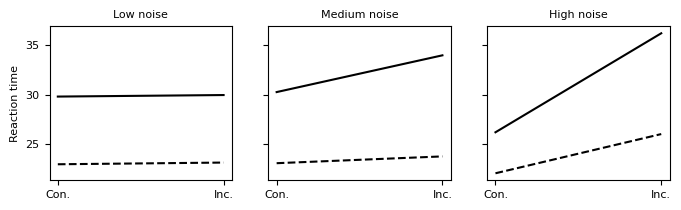

In [11]:
betas = np.array([1e5, 1e3, 1e2])
fig, axs = plt.subplots(1, len(betas), sharey=True, figsize=(8,2))

for beta, ax in zip(betas, axs):
    foo = [Bern3Diff(theta=0.7, cost=-.005, sigma=(0.7,0.7), task_prior=tp, state_range=30, update_rule='softmax', inv_temp=beta) for tp in task_priors]
    rt_inc = [performance(DiffSim(f, (False, True)), niter=int(1e4))[0] for f in foo]
    rt_con = [performance(DiffSim(f, (True, True)), niter=int(1e4))[0] for f in foo]

    ax.plot([0, 1], [rt_con[2], rt_inc[2]], linestyle='--', color='black', label="Repeat")
    ax.plot([0, 1], [rt_con[0], rt_inc[0]], color='black', label="Switch")
    ax.set_xticks((0, 1), labels=("Con.", "Inc."))

for ax, title in zip(axs, ("Low noise", "Medium noise", "High noise")):
    ax.set_title(title, fontsize="medium")

axs[0].set_ylabel("Reaction time")

In [12]:
fig.savefig("tempalt.pdf")

46
45
45
56
66
48
50
50
50


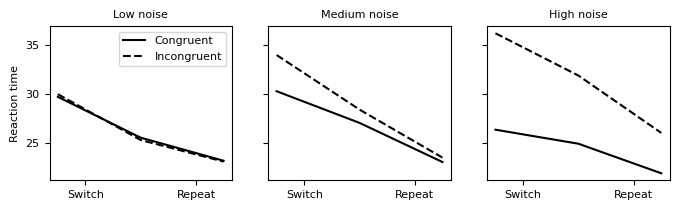

In [ ]:
betas = np.array([1e5, 1e3, 1e2])
fig, axs = plt.subplots(1, len(betas), sharey=True, figsize=(8,2))

for beta, ax in zip(betas, axs):
    foo = [Bern3Diff(theta=0.7, cost=-.005, sigma=(0.7,0.7), task_prior=tp, state_range=30, update_rule='softmax', inv_temp=beta) for tp in task_priors]
    rt_inc = [performance(DiffSim(f, (False, True)), niter=int(1e4))[0] for f in foo]
    rt_con = [performance(DiffSim(f, (True, True)), niter=int(1e4))[0] for f in foo]

    ax.plot(task_priors, rt_con, color='black', label='Congruent')
    ax.plot(task_priors, rt_inc, linestyle='--', color='black', label='Incongruent')
    ax.set_xticks((0.3,0.7), labels=("Switch", "Repeat"))

for ax, title in zip(axs, ("Low noise", "Medium noise", "High noise")):
    ax.set_title(title, fontsize="medium")

axs[0].set_ylabel("Reaction time")
axs[0].legend()

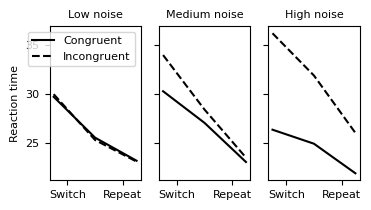

In [350]:
fig.set_figwidth(4)
fig.set_figheight(2)
fig.savefig("turnuptheheat.pdf")
fig